# ExSeq_VISp

In [1]:
import warnings
warnings.filterwarnings("ignore")
import MENDER
import scanpy as sc
import pandas as pd
import numpy as np
from sklearn.metrics import *
import time

In [8]:
## load the data using pysodb, please install pysodb in advance [https://pysodb.readthedocs.io/en/latest/]
import pysodb
sodb = pysodb.SODB()
adata_raw = sodb.load_experiment('Alon2021Expansion','mouse')




load experiment[mouse] in dataset[Alon2021Expansion]


In [9]:
# input parameters of MENDER
scale = 6

# the raduis was estimated by msm.estimate_radius()
radius = 300


# record running time 
time_st = time.time()


adata = adata_raw.copy()



######### determine cell state using standard Leiden [start]  #########
# this step can be optionally skipped if reliable cell type annotation is available
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=4000)
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)

sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata,resolution=2,key_added='ct',random_state=666)
adata.obs['ct'] = adata.obs['ct'].astype('category')
######### determine cell state using standard Leiden [end]  #########


# main body of MENDER
msm = MENDER.MENDER_single(
    adata,
    # determine which cell state to use
    # we use the cell state got by Leiden
    ct_obs='ct',
    random_seed=666
)


# set the MENDER parameters


msm.set_MENDER_para(
    # default of n_scales is 6
    n_scales=scale, 
    
    # for single cell data, nn_mode is set to 'radius' 
    nn_mode='radius',
    
    # default of n_scales is 15 um (see the manuscript for why).
    # MENDER also provide a function 'estimate_radius' for estimating the radius
    nn_para=radius, 

)
# construct the context representation
msm.run_representation(
    # the number of processings
)

# set the spatial clustering parameter
# positive values for the expected number of domains
# negative values for the clustering resolution
msm.run_clustering_normal(-0.5)

time_ed = time.time()
time_cost = time_ed-time_st




scale 0, median #cells per radius (r=300): 1.0
scale 1, median #cells per radius (r=300): 4.0
scale 2, median #cells per radius (r=300): 6.0
scale 3, median #cells per radius (r=300): 8.0
scale 4, median #cells per radius (r=300): 11.0
scale 5, median #cells per radius (r=300): 12.0


MENDER prediction


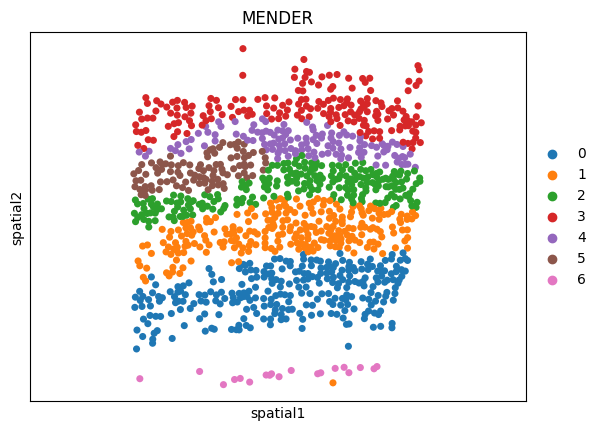

In [10]:
# the plot function has two parameters
# obs: the observation to plot
# gt_obs: the ground truth observation to compute NMI and ARI, can be set to None if not available
msm.output_cluster(obs='MENDER')
print('MENDER prediction')

In [11]:
print(f'running time: {time_cost} s')

running time: 1.8198657035827637 s


In [12]:
msm.adata_MENDER.write_h5ad('dump/ExSeq.h5ad')

